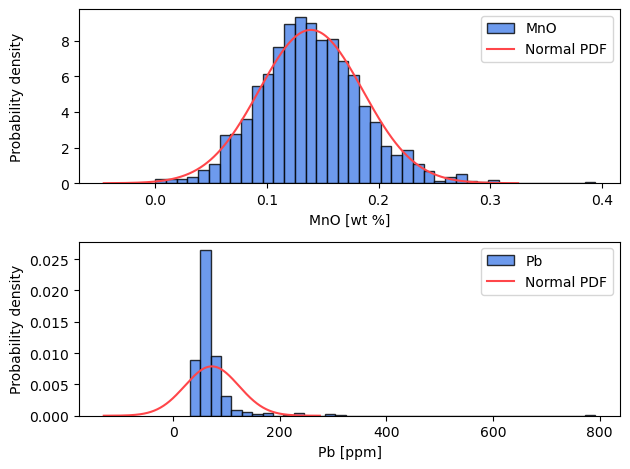

In [11]:
import pandas as pd              # Mengimpor pandas untuk membaca dan mengolah data Excel
import matplotlib.pyplot as plt  # Mengimpor matplotlib untuk membuat grafik
from scipy.stats import norm     # Mengimpor distribusi normal dari scipy
import numpy as np              # Mengimpor numpy untuk komputasi numerik

# Membaca data dari file Excel (dua sheet berbeda)
my_dataset_majors = pd.read_excel(
    'Smith_glass_post_NYT_data.xlsx',
    sheet_name='Supp_majors'
)

my_dataset_traces = pd.read_excel(
    'Smith_glass_post_NYT_data.xlsx',
    sheet_name='Supp_traces'
)


fig = plt.figure()
# Membuat figure untuk menampung subplot


# =========================================
# SUBPLOT 1: MnO (major element)
# =========================================

MnO = my_dataset_majors.MnO
# Mengambil data MnO (wt%)

ax1 = fig.add_subplot(2, 1, 1)
# Membuat subplot 1 (2 baris, 1 kolom)

ax1.hist(
    MnO,
    bins='auto',
    density=True,
    color='#4881e9',
    edgecolor='k',
    label='MnO',
    alpha=0.8
)
# Histogram MnO:
# density=True → jadi probability density
# alpha → transparansi

a_mean = MnO.mean()
# Menghitung rata-rata MnO

std_dev = MnO.std()
# Menghitung standar deviasi MnO

x = np.linspace(a_mean - 4*std_dev, a_mean + 4*std_dev, 1000)
# Membuat range x untuk kurva normal

pdf = norm.pdf(x, loc=a_mean, scale=std_dev)
# Menghitung PDF distribusi normal MnO

ax1.plot(
    x,
    pdf,
    linewidth=1.5,
    color='#ff464a',
    label='Normal PDF'
)
# Overlay kurva normal pada histogram MnO

ax1.set_xlabel('MnO [wt %]')
# Label sumbu X

ax1.set_ylabel('Probability density')
# Label sumbu Y

ax1.legend()
# Menampilkan legenda


# =========================================
# SUBPLOT 2: Pb (trace element)
# =========================================

Pb = my_dataset_traces.Pb
# Mengambil data Pb (ppm)

Pb = Pb.dropna(how='any')
# Menghapus nilai NaN (data kosong)

ax2 = fig.add_subplot(2, 1, 2)
# Membuat subplot 2

ax2.hist(
    Pb,
    bins='auto',
    density=True,
    color='#4881e9',
    edgecolor='k',
    label='Pb',
    alpha=0.8
)
# Histogram Pb dengan normalisasi PDF

a_mean = Pb.mean()
# Menghitung rata-rata Pb

std_dev = Pb.std()
# Menghitung standar deviasi Pb

x = np.linspace(a_mean - 4*std_dev, a_mean + 4*std_dev, 1000)
# Range x untuk distribusi normal Pb

pdf = norm.pdf(x, loc=a_mean, scale=std_dev)
# PDF normal Pb

ax2.plot(
    x,
    pdf,
    linewidth=1.5,
    color='#ff464a',
    label='Normal PDF'
)
# Overlay kurva normal Pb

ax2.set_xlabel('Pb [ppm]')
# Label sumbu X

ax2.set_ylabel('Probability density')
# Label sumbu Y

ax2.legend()
# Menampilkan legenda


fig.align_ylabels()
# Menyelaraskan label Y antar subplot agar rapi

fig.tight_layout()
# Mengatur layout agar tidak overlap

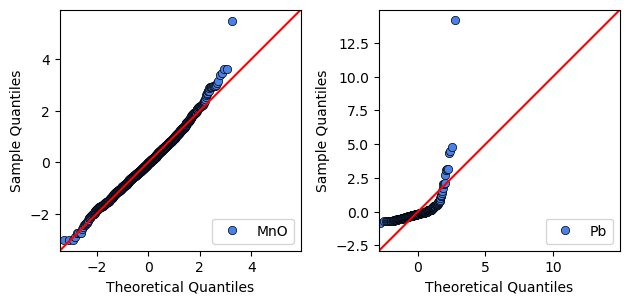

In [12]:
import statsmodels.api as sm  
# Mengimpor statsmodels untuk analisis statistik (termasuk QQ plot)

fig = plt.figure()
# Membuat figure kosong untuk menampung subplot


# =========================================
# SUBPLOT 1: QQ PLOT MnO
# =========================================

ax1 = fig.add_subplot(1, 2, 1)
# Membuat subplot 1 (1 baris, 2 kolom, posisi 1)

sm.qqplot(
    data=MnO,
    fit=True,
    line="45",
    ax=ax1,
    markerfacecolor='#4881e9',
    markeredgewidth='0.5',
    markeredgecolor='k',
    label='MnO'
)
# Membuat QQ plot untuk MnO:
# data=MnO → data yang diuji normalitasnya
# fit=True → menyesuaikan distribusi normal berdasarkan data
# line="45" → garis referensi y = x (distribusi normal ideal)
# markerfacecolor → warna titik
# markeredgecolor → warna pinggir titik

ax1.set_aspect('equal', 'box')
# Membuat skala sumbu X dan Y sama (agar garis 45° terlihat benar)

ax1.legend(loc='lower right')
# Menampilkan legenda di kanan bawah


# =========================================
# SUBPLOT 2: QQ PLOT Pb
# =========================================

ax2 = fig.add_subplot(1, 2, 2)
# Membuat subplot 2 (posisi kanan)

sm.qqplot(
    data=Pb,
    fit=True,
    line="45",
    ax=ax2,
    markerfacecolor='#4881e9',
    markeredgewidth='0.5',
    markeredgecolor='k',
    label='Pb'
)
# QQ plot untuk Pb (trace element)
# Digunakan untuk mengecek apakah data mengikuti distribusi normal

ax2.set_aspect('equal', 'box')
# Menyamakan skala sumbu X dan Y

ax2.legend(loc='lower right')
# Menampilkan legenda di kanan bawah


fig.tight_layout()
# Mengatur layout agar subplot tidak tumpang tindih

In [13]:
def returns_normal_tests(my_data):
    # Fungsi untuk melakukan beberapa uji normalitas pada data

    from scipy.stats import shapiro, anderson, normaltest
    # Mengimpor 3 uji statistik:
    # - Shapiro-Wilk (untuk sample kecil–menengah)
    # - D’Agostino and Pearson (normaltest)
    # - Anderson-Darling (lebih detail multi threshold)

    print('---------------------------------------------')
    # Garis pemisah output

    print('')
    # Baris kosong untuk kerapian output


    # =========================================
    # SHAPIRO-WILK TEST
    # =========================================

    stat, p = shapiro(my_data)
    # Menghitung statistik dan p-value Shapiro test

    alpha = 0.05
    # Level signifikansi (5%)

    if p > alpha:
        print('Shapiro test fails to reject H0: looks normal :)')
        # Jika p > 0.05 → data dianggap normal
    else:
        print('Shapiro test rejects H0: not normal :(')
        # Jika p ≤ 0.05 → data tidak normal

    print('')
    # Baris kosong


    # =========================================
    # D’AGOSTINO & PEARSON TEST
    # =========================================

    stat, p = normaltest(my_data)
    # Menghitung uji normalitas berdasarkan skewness & kurtosis

    alpha = 0.05
    # Level signifikansi

    if p > alpha:
        print("D’Agostino and Pearson's test fails to reject H0: looks normal")
        # Data dianggap normal
    else:
        print("D’Agostino and Pearson's test rejects H0: not normal")
        # Data tidak normal

    print('')
    # Baris kosong


    # =========================================
    # ANDERSON-DARLING TEST
    # =========================================

    result = anderson(my_data)
    # Menghitung Anderson-Darling test (memberikan beberapa critical value)

    print('Anderson-Darling test:')
    # Judul output

    for sl, cv in zip(result.significance_level, result.critical_values):
        # Loop untuk setiap tingkat signifikansi

        if result.statistic < cv:
            print('%.3f: fails to reject H0: Sample looks normal' % (sl))
            # Jika statistik lebih kecil dari critical value → normal
        else:
            print('%.3f: rejects H0: Sample does not look normal' % (sl))
            # Jika lebih besar → tidak normal

    print('---------------------------------------------')
    # Garis akhir output

    print('')
    # Baris kosong


# =========================================
# PENGUJIAN DATA MnO
# =========================================

print('Original MnO sample')
# Menampilkan label data awal

returns_normal_tests(MnO)
# Menjalankan uji normalitas pada data MnO asli


# =========================================
# PENGUJIAN DATA TANPA OUTLIER
# =========================================

print('MnO sample without observations above 0.27 wt %')
# Menampilkan label dataset setelah filtering outlier

MnO_no_outliers = MnO[MnO < 0.27]
# Menghapus data MnO yang lebih besar dari 0.27 (outlier removal)

returns_normal_tests(MnO_no_outliers)
# Menjalankan uji normalitas pada data yang sudah dibersihkan

Original MnO sample
---------------------------------------------

Shapiro test rejects H0: not normal :(

D’Agostino and Pearson's test rejects H0: not normal

Anderson-Darling test:
15.000: rejects H0: Sample does not look normal
10.000: rejects H0: Sample does not look normal
5.000: rejects H0: Sample does not look normal
2.500: rejects H0: Sample does not look normal
1.000: rejects H0: Sample does not look normal
---------------------------------------------

MnO sample without observations above 0.27 wt %
---------------------------------------------

Shapiro test fails to reject H0: looks normal :)

D’Agostino and Pearson's test fails to reject H0: looks normal

Anderson-Darling test:
15.000: fails to reject H0: Sample looks normal
10.000: fails to reject H0: Sample looks normal
5.000: fails to reject H0: Sample looks normal
2.500: fails to reject H0: Sample looks normal
1.000: fails to reject H0: Sample looks normal
---------------------------------------------



C:\Users\MSI MODERN\AppData\Local\Temp\ipykernel_17016\2184398954.py:63: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  result = anderson(my_data)


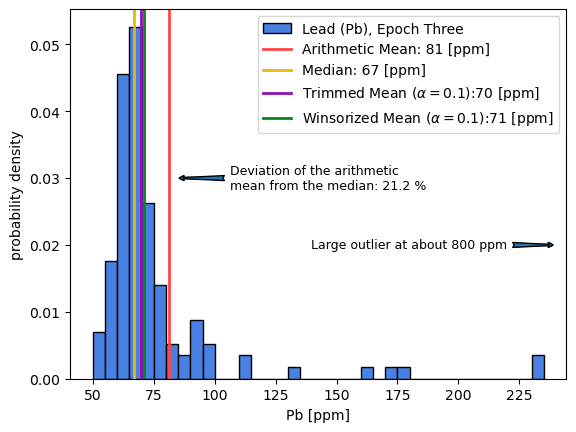

In [14]:
import pandas as pd              # Mengimpor pandas untuk membaca dan mengolah data Excel
import numpy as np              # Mengimpor NumPy untuk operasi numerik
from scipy.stats.mstats import winsorize  # Winsorization (mengurangi pengaruh outlier)
from scipy.stats import trim_mean         # Mean yang dipotong (trimmed mean)
import matplotlib.pyplot as plt  # Mengimpor matplotlib untuk plotting

# Membaca data Excel (sheet index 1)
my_dataset = pd.read_excel('Smith_glass_post_NYT_data.xlsx', sheet_name=1)

el = 'Pb'
# Menentukan elemen yang dianalisis (Pb = lead)

# Memfilter data hanya untuk epoch "three-b"
my_sub_dataset = my_dataset[my_dataset.Epoch == 'three-b']

# Menghapus data kosong (NaN) pada kolom Pb
my_sub_dataset = my_sub_dataset.dropna(subset=[el])


# =========================================
# STATISTIK DESKRIPTIF ROBUST
# =========================================

fig, ax = plt.subplots()
# Membuat figure dan axes

a_mean = my_sub_dataset[el].mean()
# Menghitung mean aritmatika (sensitif terhadap outlier)

median = my_sub_dataset[el].median()
# Menghitung median (lebih robust terhadap outlier)

trimmed_mean = trim_mean(my_sub_dataset[el], proportiontocut=0.1)
# Menghitung trimmed mean (10% data teratas & terbawah dibuang)

winsorized_mean = np.mean(winsorize(my_sub_dataset[el], limits=0.1))
# Menghitung winsorized mean (outlier tidak dibuang, tapi dipotong ke batas)

delta = 100 * (a_mean - median) / median
# Menghitung deviasi relatif mean terhadap median (%)


# =========================================
# HISTOGRAM DISTRIBUSI Pb
# =========================================

bins = np.arange(50, 240, 5)
# Membuat bin histogram dari 50 sampai 240 dengan interval 5

ax.hist(
    my_sub_dataset[el],
    density=True,
    edgecolor='k',
    color='#4881e1',
    bins=bins,
    label='Lead (Pb), Epoch Three'
)
# Histogram distribusi Pb (dinormalisasi menjadi probability density)


# =========================================
# GARIS STATISTIK (MEAN, MEDIAN, DLL)
# =========================================

ax.axvline(
    a_mean,
    color='#ff464a',
    linewidth=2,
    label='Arithmetic Mean: {:.0f} [ppm]'.format(a_mean)
)
# Garis mean aritmatika

ax.axvline(
    median,
    color='#ebb60d',
    linewidth=2,
    label='Median: {:.0f} [ppm]'.format(median)
)
# Garis median

ax.axvline(
    trimmed_mean,
    color='#8f10b3',
    linewidth=2,
    label=r'Trimmed Mean ($\alpha = 0.1$):' + '{:.0f} [ppm]'.format(trimmed_mean)
)
# Garis trimmed mean (10% trimming)

ax.axvline(
    winsorized_mean,
    color='#07851e',
    linewidth=2,
    label=r'Winsorized Mean ($\alpha = 0.1$):' + '{:.0f} [ppm]'.format(winsorized_mean)
)
# Garis winsorized mean


# =========================================
# LABEL & ANNOTATION
# =========================================

ax.set_xlabel(el + " [ppm]")
# Label sumbu X

ax.set_ylabel('probability density')
# Label sumbu Y

ax.legend()
# Menampilkan legenda


ax.annotate(
    'Large outlier at about 800 ppm',
    (240, 0.02),
    (220, 0.02),
    ha="right",
    va="center",
    size=9,
    arrowprops=dict(arrowstyle='fancy')
)
# Anotasi untuk menunjukkan outlier pada data Pb

ax.annotate(
    'Deviation of the arithmetic\nmean from the median: {:.1f} %'.format(delta),
    (a_mean + 3, 0.03),
    (a_mean + 25, 0.03),
    ha="left",
    va="center",
    size=9,
    arrowprops=dict(arrowstyle='fancy')
)
# Anotasi selisih mean vs median dalam persen


plt.show()
# Menampilkan grafik

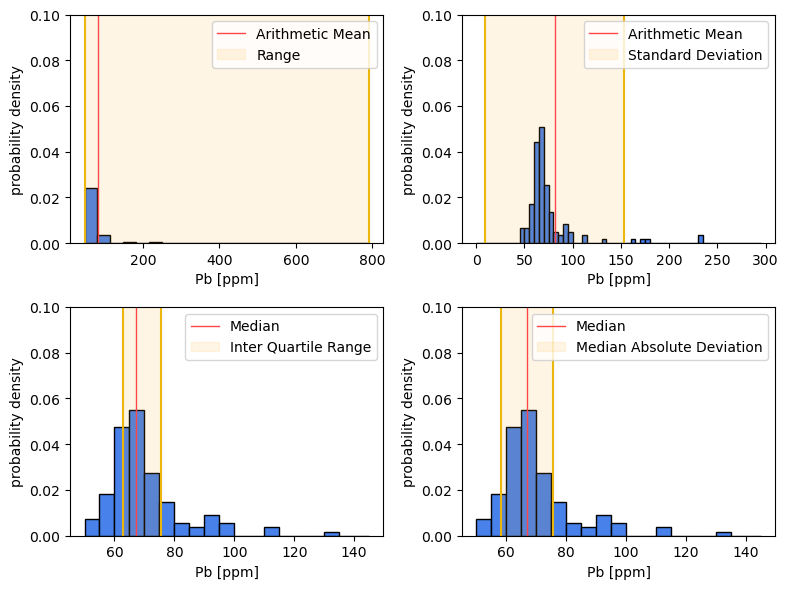

In [15]:
import pandas as pd              # Mengimpor pandas untuk membaca data Excel
import numpy as np              # Mengimpor NumPy untuk perhitungan numerik
from scipy import stats         # Mengimpor statistik (median absolute deviation, dll.)
import matplotlib.pyplot as plt # Mengimpor matplotlib untuk plotting

# =========================================
# MEMBACA & MENYARING DATA
# =========================================

my_dataset = pd.read_excel(
    'Smith_glass_post_NYT_data.xlsx',
    sheet_name=1
)
# Membaca data dari Excel sheet ke-1

el = 'Pb'
# Menentukan elemen yang dianalisis (Lead / Pb)

my_sub_dataset = my_dataset[my_dataset.Epoch == 'three-b']
# Memfilter data hanya untuk epoch "three-b"

my_sub_dataset = my_sub_dataset.dropna(subset=[el])
# Menghapus data kosong pada kolom Pb


# =========================================
# STATISTIK DASAR
# =========================================

a_mean = my_sub_dataset[el].mean()
# Mean aritmatika

median = my_sub_dataset[el].median()
# Median data


# =========================================
# UKURAN SEBARAN (SCALE MEASURES)
# =========================================

range_values = [
    my_sub_dataset[el].min(),
    my_sub_dataset[el].max()
]
# Range (nilai minimum dan maksimum)

std_dev_values = [
    a_mean - my_sub_dataset[el].std(),
    a_mean + my_sub_dataset[el].std()
]
# Standard deviation interval (mean ± 1σ)

IQR_values = [
    np.percentile(my_sub_dataset[el], 25, method='midpoint'),
    np.percentile(my_sub_dataset[el], 75, method='midpoint')
]
# Interquartile range (Q1 dan Q3)

MADn_values = [
    median - stats.median_abs_deviation(my_sub_dataset[el], scale='normal'),
    median + stats.median_abs_deviation(my_sub_dataset[el], scale='normal')
]
# Median Absolute Deviation (MAD) berbasis median


# =========================================
# PERSIAPAN UNTUK PLOT MULTI-SKALA
# =========================================

scales_values = [
    range_values,
    std_dev_values,
    IQR_values,
    MADn_values
]
# Menggabungkan semua metode penyebaran data

scale_labels = [
    'Range',
    'Standard Deviation',
    'Inter Quartile Range',
    'Median Absolute Deviation'
]
# Label untuk masing-masing metode

locations = [a_mean, a_mean, median, median]
# Lokasi garis tengah (mean atau median)

location_labels = [
    'Arithmetic Mean',
    'Arithmetic Mean',
    'Median',
    'Median'
]
# Label garis tengah

binnings = [
    'auto',
    np.arange(0, 300, 5),
    np.arange(50, 150, 5),
    np.arange(50, 150, 5)
]
# Pengaturan bin histogram berbeda untuk tiap subplot

indexes = [1, 2, 3, 4]
# Posisi subplot dalam grid 2x2


# =========================================
# VISUALISASI PERBANDINGAN SKALA
# =========================================

fig = plt.figure(figsize=(8,6))
# Membuat figure ukuran 8x6 inch

for scale_values, location, scale_label, location_label, bins, index in zip(
    scales_values,
    locations,
    scale_labels,
    location_labels,
    binnings,
    indexes
):
    # Loop untuk membuat 4 subplot sekaligus

    ax = fig.add_subplot(2, 2, index)
    # Membuat subplot 2x2

    ax.hist(
        my_sub_dataset[el],
        density=True,
        edgecolor='k',
        color='#4881e9',
        bins=bins
    )
    # Histogram distribusi Pb

    ax.axvline(
        location,
        color='#ff464a',
        linewidth=1,
        label=location_label
    )
    # Garis mean atau median

    ax.axvline(
        scale_values[0],
        color='#ebb60d'
    )
    # Batas bawah ukuran sebaran

    ax.axvline(
        scale_values[1],
        color='#ebb60d'
    )
    # Batas atas ukuran sebaran

    ax.axvspan(
        scale_values[0],
        scale_values[1],
        alpha=0.1,
        color='orange',
        label=scale_label
    )
    # Area sebaran data (visualisasi interval)

    ax.set_xlabel(el + " [ppm]")
    # Label sumbu X

    ax.set_ylabel('probability density')
    # Label sumbu Y

    ax.set_ylim(0, 0.1)
    # Membatasi skala Y agar semua subplot konsisten

    ax.legend(loc='upper right')
    # Menampilkan legenda


fig.tight_layout()
# Mengatur layout agar tidak overlap

<>:85: SyntaxWarning: invalid escape sequence '\p'
<>:85: SyntaxWarning: invalid escape sequence '\p'
C:\Users\MSI MODERN\AppData\Local\Temp\ipykernel_17016\3877610868.py:85: SyntaxWarning: invalid escape sequence '\p'
  label=loc_label + " as $\psi$: location at {:.1f} [ppm]".format(h_loc)


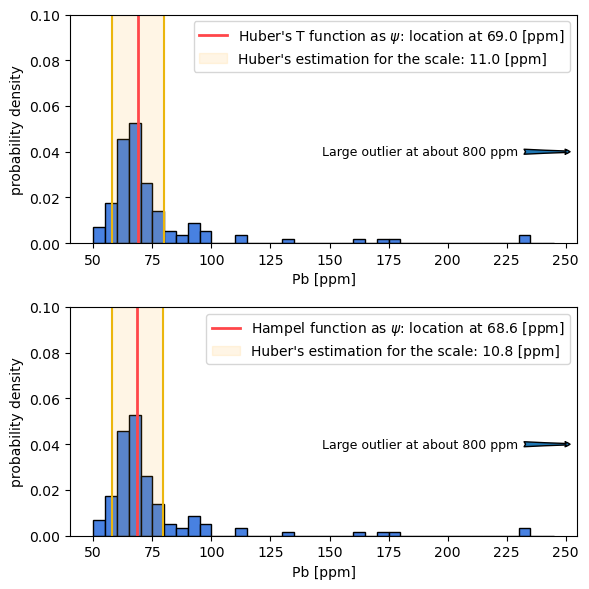

In [16]:
import pandas as pd              # Mengimpor pandas untuk membaca data Excel
import numpy as np              # Mengimpor NumPy untuk operasi numerik
import statsmodels.api as st    # Mengimpor statsmodels (untuk robust statistics)
import matplotlib.pyplot as plt # Mengimpor matplotlib untuk plotting

# =========================================
# MEMBACA & MENYARING DATA
# =========================================

my_dataset = pd.read_excel(
    'Smith_glass_post_NYT_data.xlsx',
    sheet_name=1
)
# Membaca dataset dari Excel sheet ke-1

el = 'Pb'
# Menentukan elemen yang dianalisis (Lead)

my_sub_dataset = my_dataset[my_dataset.Epoch == 'three-b']
# Memfilter data hanya untuk epoch "three-b"

my_sub_dataset = my_sub_dataset.dropna(subset=[el])
# Menghapus nilai NaN pada kolom Pb


# =========================================
# ROBUST STATISTICAL FUNCTIONS
# =========================================

norms = [
    st.robust.norms.HuberT(t=1.345),
    st.robust.norms.Hampel(a=2.0, b=4.0, c=8.0)
]
# Dua fungsi robust loss:
# - HuberT → kombinasi L2 (normal) & L1 (robust terhadap outlier)
# - Hampel → lebih agresif dalam menolak outlier

loc_labels = [
    r"Huber's T function",
    r"Hampel function"
]
# Label untuk masing-masing metode

indexes = [1, 2]
# Posisi subplot


# =========================================
# VISUALISASI ROBUST ESTIMATOR
# =========================================

fig = plt.figure(figsize=(6,6))
# Membuat figure ukuran 6x6 inch

for norm, loc_label, index in zip(norms, loc_labels, indexes):
    # Loop untuk masing-masing estimator robust

    huber_proposal_2 = st.robust.Huber(c=1.5, norm=norm)
    # Membuat estimator Huber robust dengan fungsi loss tertentu

    h_loc, h_scale = huber_proposal_2(my_sub_dataset[el])
    # Menghitung:
    # h_loc   → estimasi lokasi (mean robust)
    # h_scale → estimasi skala (robust dispersion)

    ax = fig.add_subplot(2, 1, index)
    # Membuat subplot 2 baris 1 kolom

    bins = np.arange(50, 250, 5)
    # Bin histogram untuk Pb

    ax.hist(
        my_sub_dataset[el],
        density=True,
        edgecolor='k',
        color='#4881e1',
        bins=bins
    )
    # Histogram distribusi Pb

    ax.axvline(
        h_loc,
        color='#ff464a',
        linewidth=2,
        label=loc_label + " as $\psi$: location at {:.1f} [ppm]".format(h_loc)
    )
    # Garis lokasi robust estimator (center)

    ax.axvline(
        h_loc + h_scale,
        color='#ebb60d'
    )
    # Batas atas skala robust

    ax.axvline(
        h_loc - h_scale,
        color='#ebb60d'
    )
    # Batas bawah skala robust

    ax.axvspan(
        h_loc + h_scale,
        h_loc - h_scale,
        alpha=0.1,
        color='orange',
        label="Huber's estimation for the scale: {:.1f} [ppm]".format(h_scale)
    )
    # Area rentang skala robust (±1 scale)

    ax.set_xlabel(el + " [ppm]")
    # Label sumbu X

    ax.set_ylabel('probability density')
    # Label sumbu Y

    ax.set_ylim(0, 0.1)
    # Membatasi skala Y agar grafik konsisten

    ax.legend(loc='upper right')
    # Menampilkan legenda

    ax.annotate(
        'Large outlier at about 800 ppm',
        (253, 0.04),
        (230, 0.04),
        ha='right',
        va='center',
        size=9,
        arrowprops=dict(arrowstyle='fancy')
    )
    # Menandai outlier besar pada data Pb

fig.tight_layout()
# Mengatur layout agar subplot tidak overlap